# Phase 1 — Data Exploration
**AAI-511 · Composer Identification via Deep Learning**

File counts per composer across train/dev/test splits, average MIDI duration per composer, and MIDI file validation.

In [ ]:
#Import libraries
import os
import pretty_midi
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


In [ ]:
# 1. File Counts per Composer
DATA_DIR = 'data'
splits = ['train', 'dev', 'test']
records = []

for split in splits:
    split_dir = os.path.join(DATA_DIR, split)
    for composer in sorted(os.listdir(split_dir)):
        composer_dir = os.path.join(split_dir, composer)
        if not os.path.isdir(composer_dir):
            continue
        files = [f for f in os.listdir(composer_dir) if f.endswith('.mid')]
        records.append({'split': split, 'composer': composer.capitalize(), 'count': len(files)})

df = pd.DataFrame(records)
pivot = df.pivot(index='composer', columns='split', values='count').fillna(0).astype(int)
pivot['total'] = pivot.sum(axis=1)
pivot = pivot[['train', 'dev', 'test', 'total']]
print(pivot.to_string())

split        train  dev  test  total
composer                            
Bach            42    4     4     50
Bartok          41    4     4     49
Byrd            42    4     4     50
Chopin          41    4     4     49
Handel          41    4     4     49
Hummel          42    4     4     50
Mendelssohn     41    4     4     49
Mozart          41    4     4     49
Schumann        38    3     3     44


In [8]:
# 2. Average Duration per Composer (train set)
duration_records = []

for composer in sorted(os.listdir(os.path.join(DATA_DIR, 'train'))):
    composer_dir = os.path.join(DATA_DIR, 'train', composer)
    if not os.path.isdir(composer_dir):
        continue
    for fname in os.listdir(composer_dir):
        if not fname.endswith('.mid'):
            continue
        fpath = os.path.join(composer_dir, fname)
        try:
            midi = pretty_midi.PrettyMIDI(fpath)
            duration_records.append({'composer': composer.capitalize(), 'duration_s': midi.get_end_time()})
        except Exception:
            pass

df_dur = pd.DataFrame(duration_records)
summary = df_dur.groupby('composer')['duration_s'].agg(
    mean='mean', median='median', min='min', max='max', files='count'
).round(1)
summary['mean_min'] = (summary['mean'] / 60).round(2)
print(summary[['files', 'mean', 'mean_min', 'median', 'min', 'max']].to_string())

             files   mean  mean_min  median   min     max
composer                                                 
Bach            42  280.4      4.67   117.9  61.7  1047.9
Bartok          41  152.5      2.54    95.4  34.9   555.2
Byrd            42  238.2      3.97   194.0  47.3   729.6
Chopin          41  274.8      4.58   189.0  40.9  2130.7
Handel          41  246.3      4.11   216.6  26.7   686.7
Hummel          42  577.2      9.62   474.6  77.1  2039.8
Mendelssohn     41  281.4      4.69   195.1  46.0   889.1
Mozart          41  503.4      8.39   466.9  95.0  1633.0
Schumann        38  347.7      5.80   188.1  34.0  1689.7


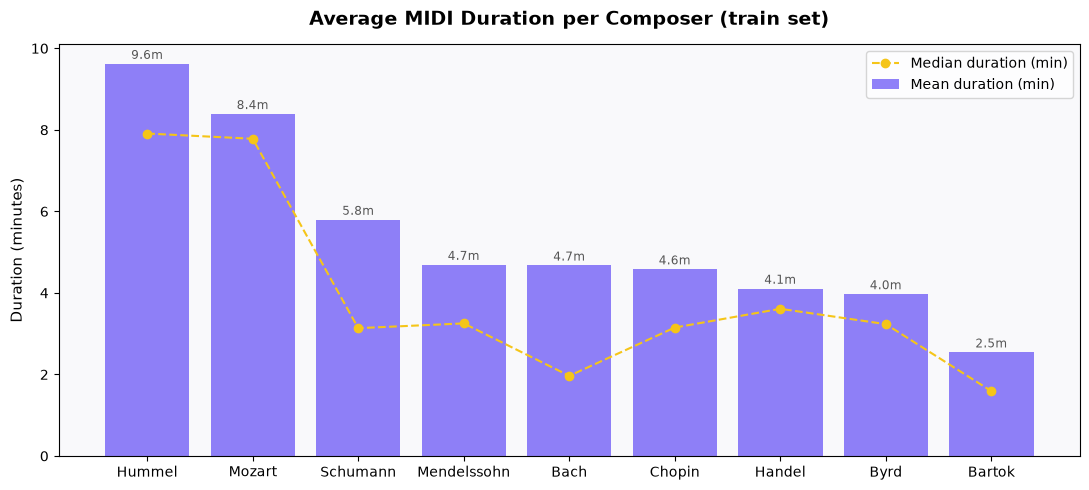

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

order = summary['mean'].sort_values(ascending=False).index.tolist()
means = summary.loc[order, 'mean'] / 60
medians = summary.loc[order, 'median'] / 60

ax.bar(order, means, color='#7c6af7', alpha=0.85, label='Mean duration (min)')
ax.plot(order, medians, 'o--', color='#f5c518', linewidth=1.5, markersize=6, label='Median duration (min)')

for i, (comp, val) in enumerate(zip(order, means)):
    ax.text(i, val + 0.05, f'{val:.1f}m', ha='center', va='bottom', fontsize=8.5, color='#555')

ax.set_ylabel('Duration (minutes)', fontsize=11)
ax.set_title('Average MIDI Duration per Composer (train set)', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10)
ax.set_facecolor('#f9f9fb')
fig.tight_layout()
plt.show()

In [10]:
# 3. Summary
total_files = pivot['total'].sum()
total_composers = len(pivot)
overall_avg = df_dur['duration_s'].mean() / 60

print(f"Composers   : {total_composers}")
print(f"Total files : {total_files}")
print(f"Avg duration: {overall_avg:.2f} minutes")
print(f"Split ratio : train={pivot['train'].sum()} | dev={pivot['dev'].sum()} | test={pivot['test'].sum()}")

Composers   : 9
Total files : 439
Avg duration: 5.38 minutes
Split ratio : train=369 | dev=35 | test=35


In [13]:
# 4. Corrupt MIDI Files
corrupt = []
valid = []

for split in ['train', 'dev', 'test']:
    split_dir = os.path.join(DATA_DIR, split)
    for composer in sorted(os.listdir(split_dir)):
        composer_dir = os.path.join(split_dir, composer)
        if not os.path.isdir(composer_dir):
            continue
        for fname in os.listdir(composer_dir):
            if not fname.endswith('.mid'):
                continue
            fpath = os.path.join(composer_dir, fname)
            try:
                pretty_midi.PrettyMIDI(fpath)
                valid.append(fpath)
            except Exception as e:
                corrupt.append({'file': fpath, 'error': str(e)})

print(f"Valid   : {len(valid)}")
print(f"Corrupt : {len(corrupt)}")

if corrupt:
    print("\nCorrupted files:")
    for c in corrupt:
        print(f"  {c['file']} — {c['error']}")
else:
    print("\nAll MIDI files are readable.")

Valid   : 439
Corrupt : 0

All MIDI files are readable.


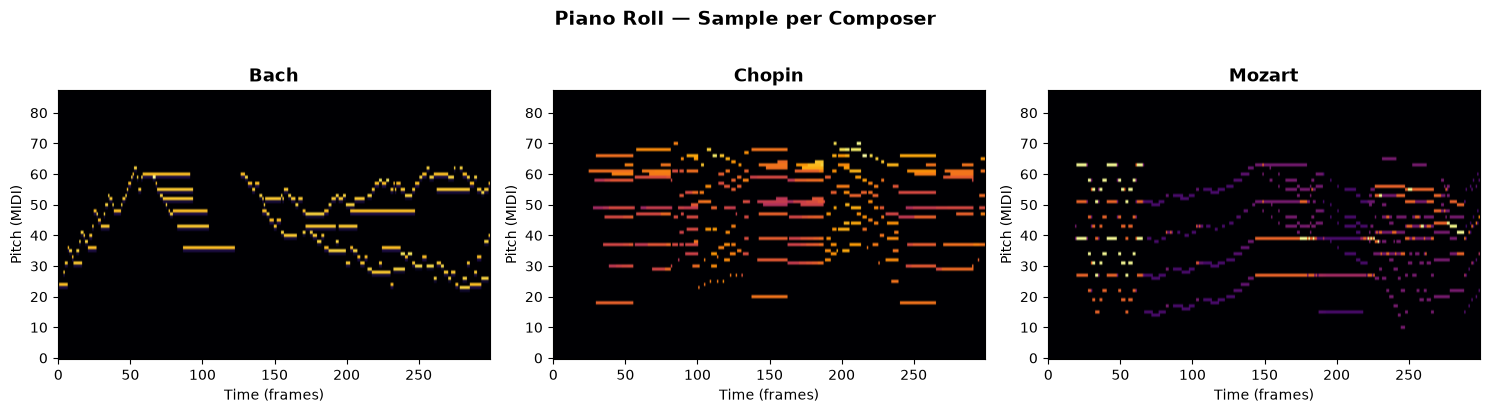

In [ ]:
# 5. Piano Roll Visualization
composers_sample = ['bach', 'chopin', 'mozart']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, composer in zip(axes, composers_sample):
    folder = os.path.join(DATA_DIR, 'train', composer)
    midi_file = sorted(f for f in os.listdir(folder) if f.endswith('.mid'))[0]
    midi = pretty_midi.PrettyMIDI(os.path.join(folder, midi_file))
    roll = midi.get_piano_roll(fs=10)  # 10 frames per second
    roll = roll[21:109, :300]          # MIDI notes 21-108 (piano range), first 30s
    ax.imshow(roll, aspect='auto', origin='lower', cmap='inferno')
    ax.set_title(composer.capitalize(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (frames)')
    ax.set_ylabel('Pitch (MIDI)')

fig.suptitle('Piano Roll — Sample per Composer', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()